# Spectral Analysis — Phase 5: Temperature Ablation & Cross-Temperature Fusion

**Goal:** Re-run selected models at T=1.0 and compare against T=1.5 (Phase 4).
Visualise how spectral signals change with temperature, then fuse features from both runs.

**Active pipeline (4 models, 2 per dataset):**
- A1: Qwen2.5-Math-1.5B on MATH-500 at T=1.0
- A2: Qwen2.5-Math-7B on MATH-500 at T=1.0
- B1: Mistral-7B on GPQA Diamond at T=1.0
- B2: Qwen2.5-7B on GPQA Diamond at T=1.0

**Research questions:**
- Q1: Does EPR stay strong on MATH-500 at T=1.0, or does it collapse?
- Q2: Does GPQA discrimination improve at T=1.0 (less noise, more structure)?
- Q3: Which spectral features are temperature-sensitive vs temperature-stable?
- Q4: Do T=1.0 and T=1.5 features carry independent information?
- Q5: Does cross-temperature fusion beat either single-temperature run?

In [1]:
from google.colab import drive, userdata
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', '-q', 'transformers>=4.40', 'datasets', 'accelerate', 'scipy'], check=True)

# Authenticate with HuggingFace (needed for gated models like Llama-3.1-8B)
try:
    from huggingface_hub import login
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token, add_to_git_credential=False)
    print('HuggingFace login OK.')
except Exception as e:
    print(f'HF login skipped: {e}')

print('Ready.')

Mounted at /content/drive
HF login skipped: Notebook does not have access to secret HF_TOKEN
Ready.


In [2]:
import os

PHASE4_DIR = '/content/drive/MyDrive/epr_spectral_phase4'
BASE_DIR   = '/content/drive/MyDrive/epr_spectral_phase5'
os.makedirs(BASE_DIR, exist_ok=True)

# ── T=1.0 pipeline — uncomment rows to add more models ────────────────────────
PIPELINE = [
    # ── MATH-500 ──
    {'tag': 'A1', 'model_id': 'Qwen/Qwen2.5-Math-1.5B-Instruct',          'dataset': 'math500', 'n_samples': 300, 'temp': 1.0, 'max_new': 1024},
    {'tag': 'A2', 'model_id': 'Qwen/Qwen2.5-Math-7B-Instruct',            'dataset': 'math500', 'n_samples': 300, 'temp': 1.0, 'max_new': 1024},
    # {'tag': 'A3', 'model_id': 'deepseek-ai/deepseek-math-7b-instruct',   'dataset': 'math500', 'n_samples': 300, 'temp': 1.0, 'max_new': 1024},
    # {'tag': 'A4', 'model_id': 'deepseek-ai/DeepSeek-R1-Distill-Llama-8B','dataset': 'math500', 'n_samples': 300, 'temp': 1.0, 'max_new': 1536},
    # ── GPQA Diamond ──
    {'tag': 'B1', 'model_id': 'mistralai/Mistral-7B-Instruct-v0.2',       'dataset': 'gpqa',    'n_samples': 198, 'temp': 1.0, 'max_new': 768},
    {'tag': 'B2', 'model_id': 'Qwen/Qwen2.5-7B-Instruct',                 'dataset': 'gpqa',    'n_samples': 198, 'temp': 1.0, 'max_new': 768},
    # {'tag': 'B3', 'model_id': 'deepseek-ai/DeepSeek-R1-Distill-Llama-8B','dataset': 'gpqa',    'n_samples': 198, 'temp': 1.0, 'max_new': 768},
    # {'tag': 'B4', 'model_id': 'meta-llama/Llama-3.1-8B-Instruct',        'dataset': 'gpqa',    'n_samples': 198, 'temp': 1.0, 'max_new': 768},
]

for cfg in PIPELINE:
    short = cfg['model_id'].split('/')[-1]
    cfg['model_short'] = short
    cfg['run_key']     = f"{short}__{cfg['dataset']}"
    cfg['run_dir']     = os.path.join(BASE_DIR, cfg['run_key'])
    os.makedirs(cfg['run_dir'], exist_ok=True)

print(f'Phase 5 pipeline: {len(PIPELINE)} runs at T=1.0')
for cfg in PIPELINE:
    done = os.path.exists(os.path.join(cfg['run_dir'], 'phase5_results.pkl'))
    print(f"  [{cfg['tag']}] {cfg['model_short']:42s} {cfg['dataset']:8s} {'DONE' if done else 'pending'}")

Phase 5 pipeline: 4 runs at T=1.0
  [A1] Qwen2.5-Math-1.5B-Instruct                 math500  DONE
  [A2] Qwen2.5-Math-7B-Instruct                   math500  DONE
  [B1] Mistral-7B-Instruct-v0.2                   gpqa     DONE
  [B2] Qwen2.5-7B-Instruct                        gpqa     DONE


In [3]:
import numpy as np, pickle, re, itertools, gc, torch, torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
from scipy.linalg import eigh
from scipy.signal import stft as scipy_stft
from tqdm import tqdm

def load_cache(path):
    return pickle.load(open(path, 'rb')) if os.path.exists(path) else {}

def save_cache(obj, path):
    pickle.dump(obj, open(path, 'wb'))

def free_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def load_model(model_id):
    from transformers import AutoModelForCausalLM, AutoTokenizer
    tok = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(
        model_id, device_map='auto', torch_dtype=torch.float16, trust_remote_code=True)
    mdl.eval(); print(f'Loaded {model_id}'); return mdl, tok

def fmt_prompt(tok, msg):
    try: return tok.apply_chat_template([{'role':'user','content':msg}],
                                         tokenize=False, add_generation_prompt=True)
    except: return f'<|user|>\n{msg}\n<|assistant|>\n'

def token_entropies_from_scores(scores, K=15):
    ents = []
    for s in scores:
        lp   = F.log_softmax(s[0], dim=-1)
        topk = torch.topk(lp, min(K, lp.shape[-1])).values
        p    = torch.exp(topk); p = p / (p.sum() + 1e-12)
        ents.append(-(p * torch.log(p + 1e-12)).sum().item())
    return ents

def generate_full(mdl, tok, prompt_msg, temperature=1.0, K=15, max_new_tokens=1024):
    prompt = fmt_prompt(tok, prompt_msg)
    inputs = tok(prompt, return_tensors='pt').to(mdl.device)
    if 'token_type_ids' in inputs: del inputs['token_type_ids']
    with torch.no_grad():
        out = mdl.generate(**inputs, max_new_tokens=max_new_tokens,
                           do_sample=True, temperature=temperature, top_k=50,
                           output_scores=True, return_dict_in_generate=True,
                           pad_token_id=tok.eos_token_id)
    gen_ids   = out.sequences[0][inputs.input_ids.shape[1]:]
    full_text = tok.decode(gen_ids, skip_special_tokens=True).strip()
    all_ents  = token_entropies_from_scores(out.scores, K)
    return full_text, all_ents

def boot_auc(y, scores, n=1000):
    y, s = np.array(y), np.array(scores)
    if len(np.unique(y)) < 2 or np.std(s) < 1e-8: return float('nan'), float('nan'), float('nan')
    base = roc_auc_score(y, s)
    rng  = np.random.default_rng(42); boots = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) < 2: continue
        boots.append(roc_auc_score(y[idx], s[idx]))
    lo, hi = np.percentile(boots, [2.5, 97.5]) if boots else (base, base)
    return base, lo, hi

def nadler_fuse(*views):
    X = np.column_stack(views); n, k = X.shape
    C = np.cov(X.T)
    if C.ndim == 0: C = np.array([[float(C)]])
    try:
        off = C - np.diag(np.diag(C))
        rs, cs = off.sum(1), off.sum(0)
        M = np.diag(rs) @ np.linalg.pinv(C) @ np.diag(cs)
        _, vecs = eigh(M)
        w = np.abs(vecs[:, -1]); w /= w.sum() + 1e-12
    except Exception: w = np.ones(k) / k
    return X @ w, w

print('Core helpers defined.')

Core helpers defined.


In [4]:
def compute_spectral_features(ents, min_len=8):
    e = np.array(ents, dtype=float); N = len(e)
    if N < min_len: return None
    e_ac     = e - e.mean()
    fft_vals = np.fft.rfft(e_ac)
    psd      = np.abs(fft_vals) ** 2
    freqs    = np.fft.rfftfreq(N)
    psd_sum  = psd.sum() + 1e-12
    psd_norm = psd / psd_sum
    spec_ent = -np.sum(psd_norm * np.log(psd_norm + 1e-12))
    low_mask  = (freqs > 0.0) & (freqs <= 0.10)
    high_mask = (freqs >= 0.40) & (freqs <= 0.50)
    low_power  = psd[low_mask].sum()  / psd_sum
    high_power = psd[high_mask].sum() / psd_sum
    hl_ratio   = high_power / (low_power + 1e-12)
    ac_mask    = freqs > 0
    dom_freq   = float(freqs[ac_mask][np.argmax(psd[ac_mask])]) if ac_mask.sum() > 0 else 0.0
    centroid   = float(np.sum(freqs[ac_mask] * psd_norm[ac_mask]) /
                       (psd_norm[ac_mask].sum() + 1e-12)) if ac_mask.sum() > 0 else 0.0
    return {'spectral_entropy': float(spec_ent), 'low_band_power': float(low_power),
            'high_band_power': float(high_power), 'hl_ratio': float(hl_ratio),
            'dominant_freq': dom_freq, 'spectral_centroid': centroid}

def compute_stft_features(ents, nperseg=16, noverlap=8, min_len=32):
    e = np.array(ents, dtype=float)
    if len(e) < min_len:
        return {'stft_max_high_power': 0.0, 'stft_spectral_entropy': 0.0}
    e_ac = e - e.mean()
    f, t, Zxx = scipy_stft(e_ac, nperseg=nperseg, noverlap=noverlap)
    psd = np.abs(Zxx) ** 2
    high_mask = f >= 0.40
    if high_mask.sum() > 0 and psd.shape[1] > 0:
        high_frac = psd[high_mask].sum(0) / (psd.sum(0) + 1e-12)
        max_local_high = float(high_frac.max())
    else:
        max_local_high = 0.0
    psd_n = psd / (psd.sum(0, keepdims=True) + 1e-12)
    frame_ent = -np.sum(psd_n * np.log(psd_n + 1e-12), axis=0)
    stft_ent = float(frame_ent.mean()) if len(frame_ent) > 0 else 0.0
    return {'stft_max_high_power': max_local_high, 'stft_spectral_entropy': stft_ent}

def compute_time_domain(ents, tail_frac=0.20, sw_window=16, sw_step=8):
    e = np.array(ents, dtype=float)
    W = max(1, int(len(e) * tail_frac))
    rpdi = float(e[-W:].mean() / (e.mean() + 1e-12))
    if len(e) >= sw_window:
        sw_vars = [np.var(e[i:i+sw_window]) for i in range(0, len(e)-sw_window+1, sw_step)]
        sw_var_peak = float(np.max(sw_vars))
    else:
        sw_var_peak = float(np.var(e))
    return {'rpdi': rpdi, 'sw_var_peak': sw_var_peak}

def extract_all_features(ents):
    e = np.array(ents, dtype=float)
    result = {'epr': float(e.mean()), 'trace_length': float(len(e))}
    gf = compute_spectral_features(ents)
    if gf is None: return None
    result.update(gf)
    result.update(compute_stft_features(ents))
    result.update(compute_time_domain(ents))
    return result

FEAT_NAMES = ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power',
              'hl_ratio', 'dominant_freq', 'spectral_centroid',
              'stft_max_high_power', 'stft_spectral_entropy', 'rpdi', 'sw_var_peak']
print(f'Feature set ({len(FEAT_NAMES)} signals): {FEAT_NAMES}')

Feature set (12 signals): ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power', 'hl_ratio', 'dominant_freq', 'spectral_centroid', 'stft_max_high_power', 'stft_spectral_entropy', 'rpdi', 'sw_var_peak']


In [5]:
from datasets import load_dataset

def load_math500(n_samples=300):
    attempts = [
        ('lighteval/MATH_500',        {},                   'test'),
        ('HuggingFaceH4/MATH-500',    {},                   'test'),
        ('EleutherAI/hendrycks_math', {'name': 'all'},      'test'),
        ('EleutherAI/hendrycks_math', {'name': 'algebra'},  'test'),
    ]
    for path, kwargs, split in attempts:
        try:
            ds = load_dataset(path, split=split, **kwargs)
            samples = [ds[i] for i in range(min(n_samples, len(ds)))]
            print(f'Loaded {len(samples)} MATH problems from {path}.')
            return samples
        except Exception as e:
            print(f'  {path} failed: {e}')
    raise RuntimeError('Could not load MATH dataset from any source.')

def math_prompt(row):
    q = row.get('problem', row.get('query', row.get('question', '')))
    return (f'Solve the following competition math problem. '
            f'Show all your work step by step, then give your final answer in \\boxed{{}}.\n\n{q}')

def extract_math_answer(text):
    m = re.search(r'\\boxed\{([^}]*)\}', text)
    if m:
        val = re.sub(r'[^\d\.\-\/\(\)]', '', m.group(1).replace(',', ''))
        if val: return val
    nums = re.findall(r'[\-\d]+(?:\.\d+)?', text.replace(',', ''))
    return nums[-1] if nums else ''

def is_correct_math(gen, gold_row):
    sol = gold_row.get('solution', gold_row.get('answer', gold_row.get('output', '')))
    p, g = extract_math_answer(gen), extract_math_answer(sol)
    if not p or not g: return False
    try: return abs(float(p) - float(g)) < 1e-6
    except: return p.strip() == g.strip()

def load_gpqa():
    ds = load_dataset('Idavidrein/gpqa', 'gpqa_diamond', split='train')
    print(f'Loaded {len(ds)} GPQA Diamond problems.')
    return list(ds)

def gpqa_prompt_and_answer(row, idx):
    rng = np.random.default_rng(idx)
    choices = [row['Correct Answer'],
               row['Incorrect Answer 1'],
               row['Incorrect Answer 2'],
               row['Incorrect Answer 3']]
    order   = rng.permutation(4)
    letters = ['A', 'B', 'C', 'D']
    shuffled = [choices[i] for i in order]
    correct_letter = letters[int(np.where(order == 0)[0][0])]
    opts = '\n'.join(f'{l}) {t}' for l, t in zip(letters, shuffled))
    prompt = (f'Answer the following graduate-level science question by selecting the best answer. '
              f'Think through your reasoning carefully.\n\n'
              f"{row['Question']}\n\n{opts}\n\n"
              f'Provide your reasoning, then state your final answer as a single letter: A, B, C, or D.')
    return prompt, correct_letter

def extract_gpqa_answer(text):
    patterns = [
        r'(?:answer is|answer:|the answer|final answer)[^A-Da-d]*([A-Da-d])\b',
        r'\b([A-Da-d])\s*(?:is correct|is the best|is the answer)',
        r'^\s*([A-Da-d])[\)\.]?\s*$',
    ]
    for p in patterns:
        matches = re.findall(p, text, re.IGNORECASE | re.MULTILINE)
        if matches: return matches[-1].upper()
    matches = re.findall(r'\b([A-D])\b', text.upper())
    return matches[-1] if matches else ''

def is_correct_gpqa(gen, correct_letter):
    return extract_gpqa_answer(gen) == correct_letter.upper()

print('Dataset loaders defined.')

Dataset loaders defined.


In [6]:
# ── Main inference pipeline ───────────────────────────────────────────────────
math500_data, gpqa_data = None, None

for cfg in PIPELINE:
    cache_path   = os.path.join(cfg['run_dir'], 'inference_cache.pkl')
    results_path = os.path.join(cfg['run_dir'], 'phase5_results.pkl')

    if os.path.exists(results_path):
        print(f"[{cfg['tag']}] {cfg['run_key']} — already complete, skipping.")
        continue

    print(f"\n{'='*60}")
    print(f"[{cfg['tag']}] {cfg['model_short']} on {cfg['dataset']} (T={cfg['temp']})")
    print(f"{'='*60}")

    if cfg['dataset'] == 'math500' and math500_data is None:
        math500_data = load_math500(300)
    if cfg['dataset'] == 'gpqa' and gpqa_data is None:
        gpqa_data = load_gpqa()

    dataset   = math500_data if cfg['dataset'] == 'math500' else gpqa_data
    n_samples = cfg['n_samples']

    cache     = load_cache(cache_path)
    remaining = [i for i in range(n_samples) if not cache.get(i, {}).get('done')]
    print(f'Cache: {n_samples - len(remaining)}/{n_samples} done. Remaining: {len(remaining)}')

    if remaining:
        model, tokenizer = load_model(cfg['model_id'])
        for i in tqdm(remaining, desc=f"{cfg['tag']} inference"):
            try:
                row = dataset[i]
                if cfg['dataset'] == 'math500':
                    prompt = math_prompt(row)
                    full_text, all_ents = generate_full(
                        model, tokenizer, prompt, cfg['temp'], max_new_tokens=cfg['max_new'])
                    correct  = is_correct_math(full_text, row)
                    gold_ref = row.get('solution', '')
                else:
                    prompt, correct_letter = gpqa_prompt_and_answer(row, i)
                    full_text, all_ents = generate_full(
                        model, tokenizer, prompt, cfg['temp'], max_new_tokens=cfg['max_new'])
                    correct  = is_correct_gpqa(full_text, correct_letter)
                    gold_ref = correct_letter
                cache[i] = {'done': True, 'full_text': full_text,
                            'all_entropies': all_ents, 'correct': correct, 'gold': gold_ref}
            except Exception as ex:
                print(f'  Error {i}: {ex}'); cache[i] = {'done': False}
            if i % 20 == 0: save_cache(cache, cache_path)
            free_memory()
        save_cache(cache, cache_path)
        del model, tokenizer; free_memory()

    # ── Feature extraction ────────────────────────────────────────────────────
    idx_ok = sorted(i for i in range(n_samples)
                    if cache.get(i, {}).get('done') and cache[i].get('all_entropies'))
    labels, feat_list, n_toks, raw_ents = [], [], [], []
    for i in idx_ok:
        v = cache[i]
        ents = v['all_entropies']
        if len(ents) < 8: continue
        feats = extract_all_features(ents)
        if feats is None: continue
        labels.append(int(v['correct']))
        feat_list.append(feats)
        n_toks.append(len(ents))
        raw_ents.append(ents)

    labels      = np.array(labels)
    n_toks      = np.array(n_toks)
    feat_arrays = {name: np.array([f[name] for f in feat_list]) for name in FEAT_NAMES}
    print(f'Samples: {len(labels)} | Correct: {int(labels.sum())} ({labels.mean():.1%}) | Avg trace: {n_toks.mean():.0f} tok')

    # ── Individual AUCs ───────────────────────────────────────────────────────
    auc_map, sign_map, rows = {}, {}, []
    for name in FEAT_NAMES:
        a_p, lo_p, hi_p = boot_auc(labels,  feat_arrays[name])
        a_n, lo_n, hi_n = boot_auc(labels, -feat_arrays[name])
        if a_p >= a_n: auc, lo, hi, sign = a_p, lo_p, hi_p, +1
        else:          auc, lo, hi, sign = a_n, lo_n, hi_n, -1
        auc_map[name] = auc; sign_map[name] = sign
        rows.append((auc, name, lo, hi))
    rows.sort(reverse=True)
    print(f'\nIndividual AUCs  (T=1.0)')
    for auc, name, lo, hi in rows:
        print(f'  {name:<26} {100*auc:5.1f}%  [{100*lo:.1f}, {100*hi:.1f}]')

    # ── Nadler combinatorial fusion ───────────────────────────────────────────
    oriented = {name: feat_arrays[name] * sign_map[name] for name in FEAT_NAMES}
    rho_mat  = {}
    for a, b in itertools.combinations_with_replacement(FEAT_NAMES, 2):
        rho, _ = spearmanr(oriented[a], oriented[b])
        rho_mat[(a, b)] = rho_mat[(b, a)] = rho

    informative   = [n for n in FEAT_NAMES if auc_map[n] > 0.50]
    valid_subsets = [s for size in range(2, len(informative)+1)
                     for s in itertools.combinations(informative, size)
                     if all(abs(rho_mat[(a,b)]) < 0.75 for a,b in itertools.combinations(s, 2))]
    print(f'Valid subsets: {len(valid_subsets)}')

    subset_results = []
    for subset in tqdm(valid_subsets, desc='Nadler', leave=False):
        views = [oriented[n] for n in subset]
        fused, weights = nadler_fuse(*views)
        auc, lo, hi    = boot_auc(labels, fused)
        subset_results.append({'subset': subset, 'auc': auc, 'lo': lo, 'hi': hi,
                               'weights': {n: float(w) for n,w in zip(subset, weights)}})
    subset_results.sort(key=lambda x: -x['auc'])

    best = subset_results[0] if subset_results else None
    if best:
        print(f'Best fusion: {"+".join(best["subset"])} = {100*best["auc"]:.1f}% [{100*best["lo"]:.1f}, {100*best["hi"]:.1f}]')
        print('Weights: ' + ', '.join(f'{k}={v:.3f}' for k,v in sorted(best['weights'].items(), key=lambda x:-x[1])))

    # ── Save (includes raw data for visualisation) ────────────────────────────
    save_cache({
        'tag': cfg['tag'], 'model': cfg['model_short'], 'dataset': cfg['dataset'],
        'temp': cfg['temp'], 'n_samples': len(labels),
        'accuracy': float(labels.mean()), 'avg_trace': float(n_toks.mean()),
        'auc_map': auc_map, 'sign_map': sign_map, 'rho_mat': rho_mat,
        'subset_results': subset_results[:30], 'feat_names': FEAT_NAMES,
        'raw_entropies': raw_ents,
        'raw_labels': labels.tolist(),
        'feat_arrays': {k: v.tolist() for k, v in feat_arrays.items()},
    }, results_path)
    print(f'Saved → {results_path}')

print('\nPipeline complete.')

[A1] Qwen2.5-Math-1.5B-Instruct__math500 — already complete, skipping.
[A2] Qwen2.5-Math-7B-Instruct__math500 — already complete, skipping.
[B1] Mistral-7B-Instruct-v0.2__gpqa — already complete, skipping.
[B2] Qwen2.5-7B-Instruct__gpqa — already complete, skipping.

Pipeline complete.


In [7]:
# ── T=1.0 AUC summary table ───────────────────────────────────────────────────
all_p5 = {}
for cfg in PIPELINE:
    path = os.path.join(cfg['run_dir'], 'phase5_results.pkl')
    if os.path.exists(path):
        r = load_cache(path)
        all_p5[cfg['tag']] = r
        print(f"[{cfg['tag']}] {cfg['run_key']} loaded")
    else:
        print(f"[{cfg['tag']}] {cfg['run_key']} missing")

tags_math = [t for t in all_p5 if all_p5[t]['dataset'] == 'math500']
tags_gpqa = [t for t in all_p5 if all_p5[t]['dataset'] == 'gpqa']

for group_name, tags in [('MATH-500 (T=1.0)', tags_math), ('GPQA Diamond (T=1.0)', tags_gpqa)]:
    if not tags: continue
    print(f'\n{"="*70}\n{group_name}\n{"="*70}')
    col_w = 20
    print(f'{"Signal":<26}', end='')
    for t in tags: print(f'{all_p5[t]["model"][:18]:>{col_w}}', end='')
    print()
    print('-' * (26 + col_w * len(tags)))
    ref_aucs = all_p5[tags[0]]['auc_map']
    for sig in sorted(FEAT_NAMES, key=lambda n: -ref_aucs.get(n, 0)):
        print(f'{sig:<26}', end='')
        for t in tags: print(f'{100*all_p5[t]["auc_map"].get(sig,0):{col_w-1}.1f}%', end='')
        print()
    print(f'{"Best fusion":<26}', end='')
    for t in tags:
        sr = all_p5[t]['subset_results']
        print(f'{100*(sr[0]["auc"] if sr else 0):{col_w-1}.1f}%', end='')
    print()
    print(f'{"Accuracy":<26}', end='')
    for t in tags: print(f'{100*all_p5[t]["accuracy"]:{col_w-1}.1f}%', end='')
    print()
    print(f'\nBest fusion per model:')
    for t in tags:
        sr = all_p5[t]['subset_results']
        if sr:
            b = sr[0]
            print(f'  [{t}] {"+".join(b["subset"])} = {100*b["auc"]:.1f}% [{100*b["lo"]:.1f}, {100*b["hi"]:.1f}]')

[A1] Qwen2.5-Math-1.5B-Instruct__math500 loaded
[A2] Qwen2.5-Math-7B-Instruct__math500 loaded
[B1] Mistral-7B-Instruct-v0.2__gpqa loaded
[B2] Qwen2.5-7B-Instruct__gpqa loaded

MATH-500 (T=1.0)
Signal                      Qwen2.5-Math-1.5B-  Qwen2.5-Math-7B-In
------------------------------------------------------------------
sw_var_peak                              78.3%               86.8%
trace_length                             74.2%               85.7%
low_band_power                           71.2%               81.0%
spectral_centroid                        71.1%               81.4%
epr                                      70.2%               86.7%
dominant_freq                            69.4%               81.3%
spectral_entropy                         68.0%               62.7%
stft_max_high_power                      67.6%               52.0%
hl_ratio                                 66.8%               80.4%
rpdi                                     60.1%               84.3%
hig

## Visualizations: T=1.0 vs T=1.5

Four plots comparing T=1.0 (Phase 5, solid lines) against T=1.5 (Phase 4, dashed lines):

1. **H(n) entropy trajectories** — mean ± std over normalised token position, correct vs wrong
2. **Power Spectral Density** — average normalised PSD per group across frequency
3. **STFT heatmaps** — average time-frequency structure per group (correct/wrong × temperature)
4. **Feature distributions** — KDE of RPDI, spectral entropy, EPR, high-band power per group

Run the load cell first (loads Phase 4 inference caches and aligns samples by question index).

In [8]:
import matplotlib
matplotlib.rcParams.update({'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3})
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ── Load and align Phase 4 (T=1.5) and Phase 5 (T=1.0) caches ────────────────
aligned = {}   # tag -> {labels, p5_ents, p4_ents, p5_feats, p4_feats}

for cfg in PIPELINE:
    tag = cfg['tag']
    if tag not in all_p5:
        print(f'[{tag}] Phase 5 results missing — run inference cell first.')
        continue

    p4_cache_path = os.path.join(PHASE4_DIR, cfg['run_key'], 'inference_cache.pkl')
    p5_cache_path = os.path.join(cfg['run_dir'], 'inference_cache.pkl')

    if not os.path.exists(p4_cache_path):
        print(f'[{tag}] Phase 4 cache not found: {p4_cache_path}')
        continue
    if not os.path.exists(p5_cache_path):
        print(f'[{tag}] Phase 5 cache not found.')
        continue

    p4_cache = load_cache(p4_cache_path)
    p5_cache = load_cache(p5_cache_path)
    n        = cfg['n_samples']

    p4_valid = {i for i in range(n)
                if p4_cache.get(i, {}).get('done') and p4_cache[i].get('all_entropies')
                and len(p4_cache[i]['all_entropies']) >= 8}
    p5_valid = {i for i in range(n)
                if p5_cache.get(i, {}).get('done') and p5_cache[i].get('all_entropies')
                and len(p5_cache[i]['all_entropies']) >= 8}
    common   = sorted(p4_valid & p5_valid)
    print(f'[{tag}] Aligned samples: {len(common)}  (P4={len(p4_valid)}, P5={len(p5_valid)})')

    p5_ents, p4_ents, labels = [], [], []
    p5_feats = {n_: [] for n_ in FEAT_NAMES}
    p4_feats = {n_: [] for n_ in FEAT_NAMES}

    for i in common:
        v5 = p5_cache[i]; v4 = p4_cache[i]
        f5 = extract_all_features(v5['all_entropies'])
        f4 = extract_all_features(v4['all_entropies'])
        if f5 is None or f4 is None: continue
        labels.append(int(v5['correct']))   # T=1.0 label as ground truth
        p5_ents.append(np.array(v5['all_entropies']))
        p4_ents.append(np.array(v4['all_entropies']))
        for n_ in FEAT_NAMES:
            p5_feats[n_].append(f5[n_])
            p4_feats[n_].append(f4[n_])

    labels   = np.array(labels)
    p5_feats = {n_: np.array(v) for n_, v in p5_feats.items()}
    p4_feats = {n_: np.array(v) for n_, v in p4_feats.items()}
    aligned[tag] = {'labels': labels, 'p5_ents': p5_ents, 'p4_ents': p4_ents,
                    'p5_feats': p5_feats, 'p4_feats': p4_feats}
    print(f'  Correct: {labels.sum()}/{len(labels)} ({labels.mean():.1%})')

tags_plot = [cfg['tag'] for cfg in PIPELINE if cfg['tag'] in aligned]
print('\nReady to plot:', tags_plot)

[A1] Aligned samples: 300  (P4=300, P5=300)
  Correct: 208/300 (69.3%)
[A2] Aligned samples: 300  (P4=300, P5=300)
  Correct: 206/300 (68.7%)
[B1] Aligned samples: 198  (P4=198, P5=198)
  Correct: 61/198 (30.8%)
[B2] Aligned samples: 198  (P4=198, P5=198)
  Correct: 60/198 (30.3%)

Ready to plot: ['A1', 'A2', 'B1', 'B2']


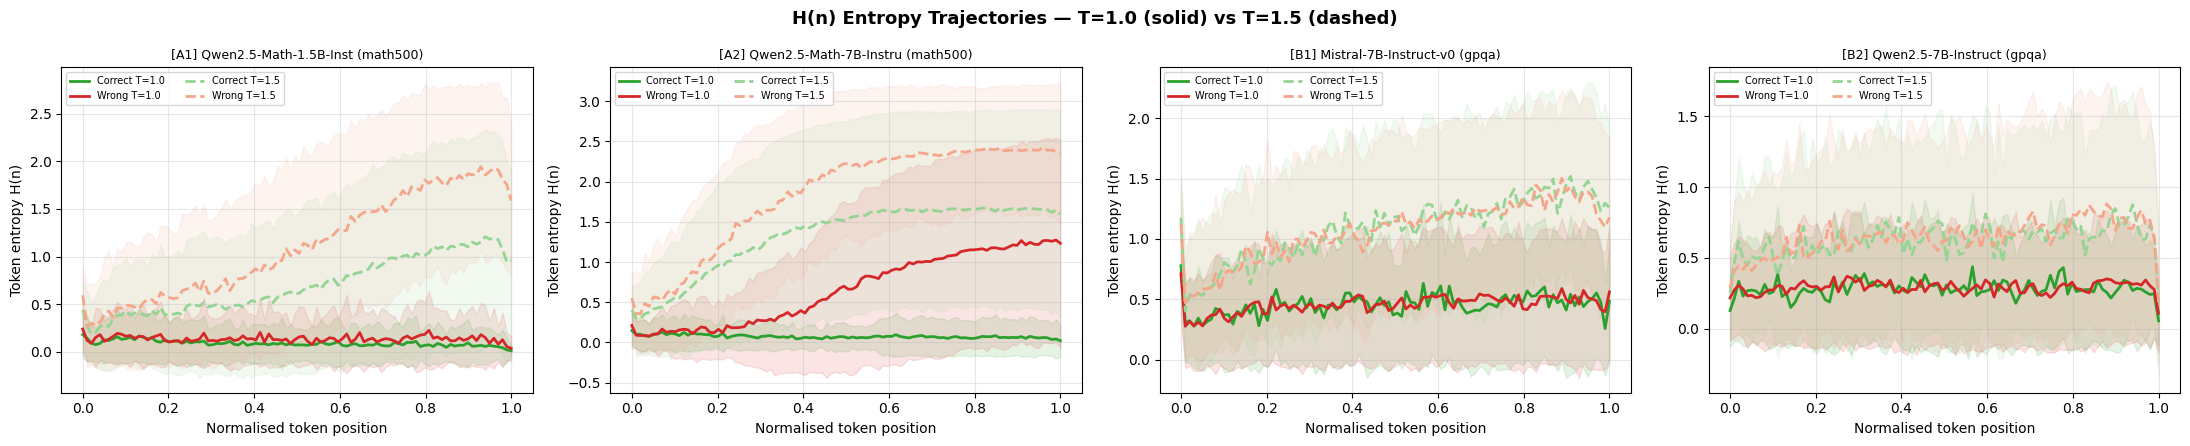

Saved: hn_trajectories.png


In [9]:
# ── Plot 1: H(n) entropy trajectories ─────────────────────────────────────────
N_GRID = 100
x_grid = np.linspace(0, 1, N_GRID)

def interp_trace(ents):
    e = np.array(ents, dtype=float)
    if len(e) < 2: return None
    return interp1d(np.linspace(0, 1, len(e)), e, kind='linear')(x_grid)

n_plots = len(tags_plot)
fig, axes = plt.subplots(1, n_plots, figsize=(5.5 * n_plots, 4.5), sharey=False)
if n_plots == 1: axes = [axes]

for ax, tag in zip(axes, tags_plot):
    d   = aligned[tag]
    lbl = all_p5[tag]['model'][:22]
    ds  = all_p5[tag]['dataset']

    for (ents_list, temp_label, c_col, w_col, ls) in [
        (d['p5_ents'], 'T=1.0', '#2ca02c', '#d62728', '-'),
        (d['p4_ents'], 'T=1.5', '#94d594', '#f5a68a', '--'),
    ]:
        c_grids = [g for e, l in zip(ents_list, d['labels'])
                   if l == 1 for g in [interp_trace(e)] if g is not None]
        w_grids = [g for e, l in zip(ents_list, d['labels'])
                   if l == 0 for g in [interp_trace(e)] if g is not None]
        for grids, col, line_lbl in [(c_grids, c_col, f'Correct {temp_label}'),
                                      (w_grids, w_col, f'Wrong {temp_label}')]:
            if not grids: continue
            arr  = np.stack(grids)
            mean = arr.mean(0); std = arr.std(0)
            ax.plot(x_grid, mean, color=col, ls=ls, lw=2, label=line_lbl)
            ax.fill_between(x_grid, mean - std, mean + std, color=col, alpha=0.12)

    ax.set_title(f'[{tag}] {lbl} ({ds})', fontsize=9)
    ax.set_xlabel('Normalised token position')
    ax.set_ylabel('Token entropy H(n)')
    ax.legend(fontsize=7, ncol=2)

plt.suptitle('H(n) Entropy Trajectories — T=1.0 (solid) vs T=1.5 (dashed)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'hn_trajectories.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: hn_trajectories.png')

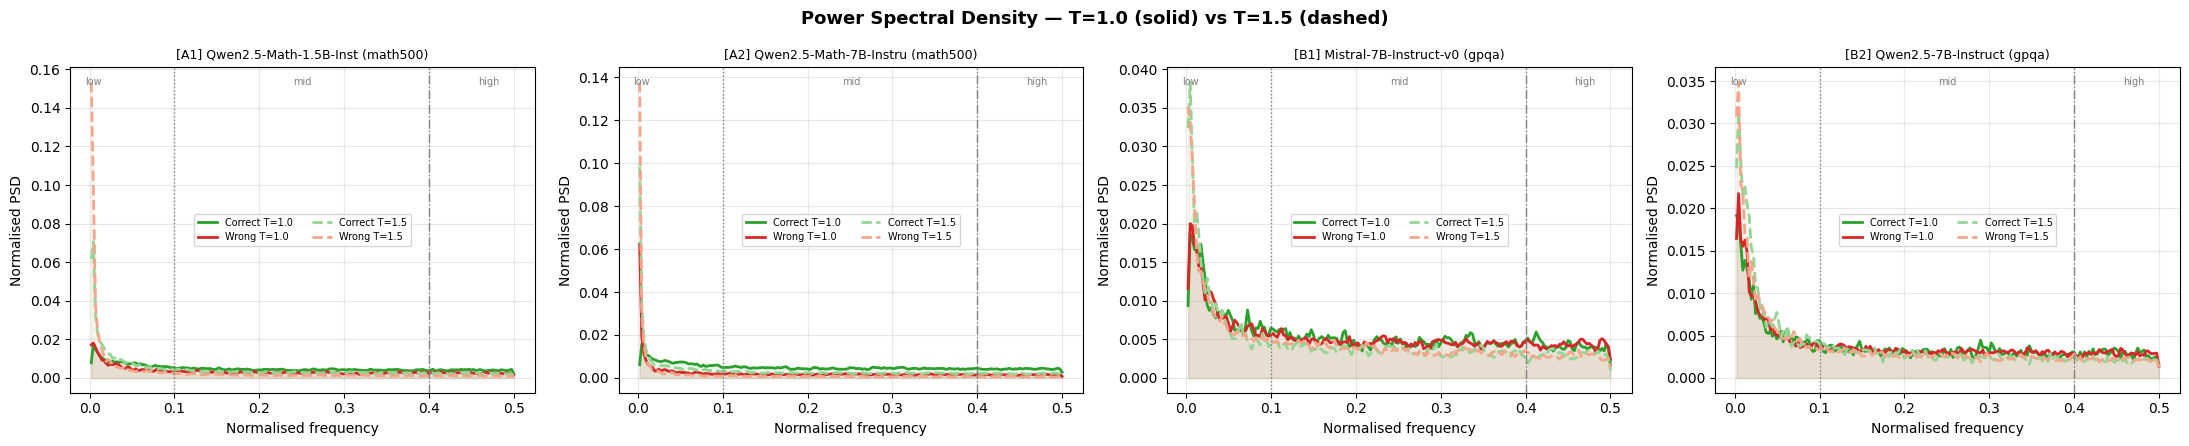

Saved: psd_comparison.png


In [10]:
# ── Plot 2: Power Spectral Density ────────────────────────────────────────────
FREQ_GRID = np.linspace(0.002, 0.5, 200)

def psd_interp(ents):
    e = np.array(ents, dtype=float) - np.mean(ents)
    N = len(e)
    if N < 8: return None
    psd   = np.abs(np.fft.rfft(e)) ** 2
    freqs = np.fft.rfftfreq(N)
    mask  = freqs > 0
    if mask.sum() < 2: return None
    psd_n = psd[mask] / (psd[mask].sum() + 1e-12)
    return interp1d(freqs[mask], psd_n, bounds_error=False, fill_value=0.0)(FREQ_GRID)

fig, axes = plt.subplots(1, n_plots, figsize=(5.5 * n_plots, 4.5), sharey=False)
if n_plots == 1: axes = [axes]

for ax, tag in zip(axes, tags_plot):
    d   = aligned[tag]
    lbl = all_p5[tag]['model'][:22]
    ds  = all_p5[tag]['dataset']

    for (ents_list, temp_label, c_col, w_col, ls) in [
        (d['p5_ents'], 'T=1.0', '#2ca02c', '#d62728', '-'),
        (d['p4_ents'], 'T=1.5', '#94d594', '#f5a68a', '--'),
    ]:
        c_psds = [p for e, l in zip(ents_list, d['labels'])
                  if l == 1 for p in [psd_interp(e)] if p is not None]
        w_psds = [p for e, l in zip(ents_list, d['labels'])
                  if l == 0 for p in [psd_interp(e)] if p is not None]
        for psds, col, line_lbl in [(c_psds, c_col, f'Correct {temp_label}'),
                                     (w_psds, w_col, f'Wrong {temp_label}')]:
            if not psds: continue
            arr  = np.stack(psds)
            mean = arr.mean(0)
            ax.plot(FREQ_GRID, mean, color=col, ls=ls, lw=2, label=line_lbl)
            ax.fill_between(FREQ_GRID, 0, mean, color=col, alpha=0.08)

    ax.axvline(0.10, color='gray', ls=':', lw=1)
    ax.axvline(0.40, color='gray', ls='-.', lw=1)
    ax.text(0.05, 0.97, 'low',  fontsize=7, color='gray', ha='center', va='top', transform=ax.transAxes)
    ax.text(0.50, 0.97, 'mid',  fontsize=7, color='gray', ha='center', va='top', transform=ax.transAxes)
    ax.text(0.90, 0.97, 'high', fontsize=7, color='gray', ha='center', va='top', transform=ax.transAxes)
    ax.set_title(f'[{tag}] {lbl} ({ds})', fontsize=9)
    ax.set_xlabel('Normalised frequency')
    ax.set_ylabel('Normalised PSD')
    ax.legend(fontsize=7, ncol=2)

plt.suptitle('Power Spectral Density — T=1.0 (solid) vs T=1.5 (dashed)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'psd_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: psd_comparison.png')

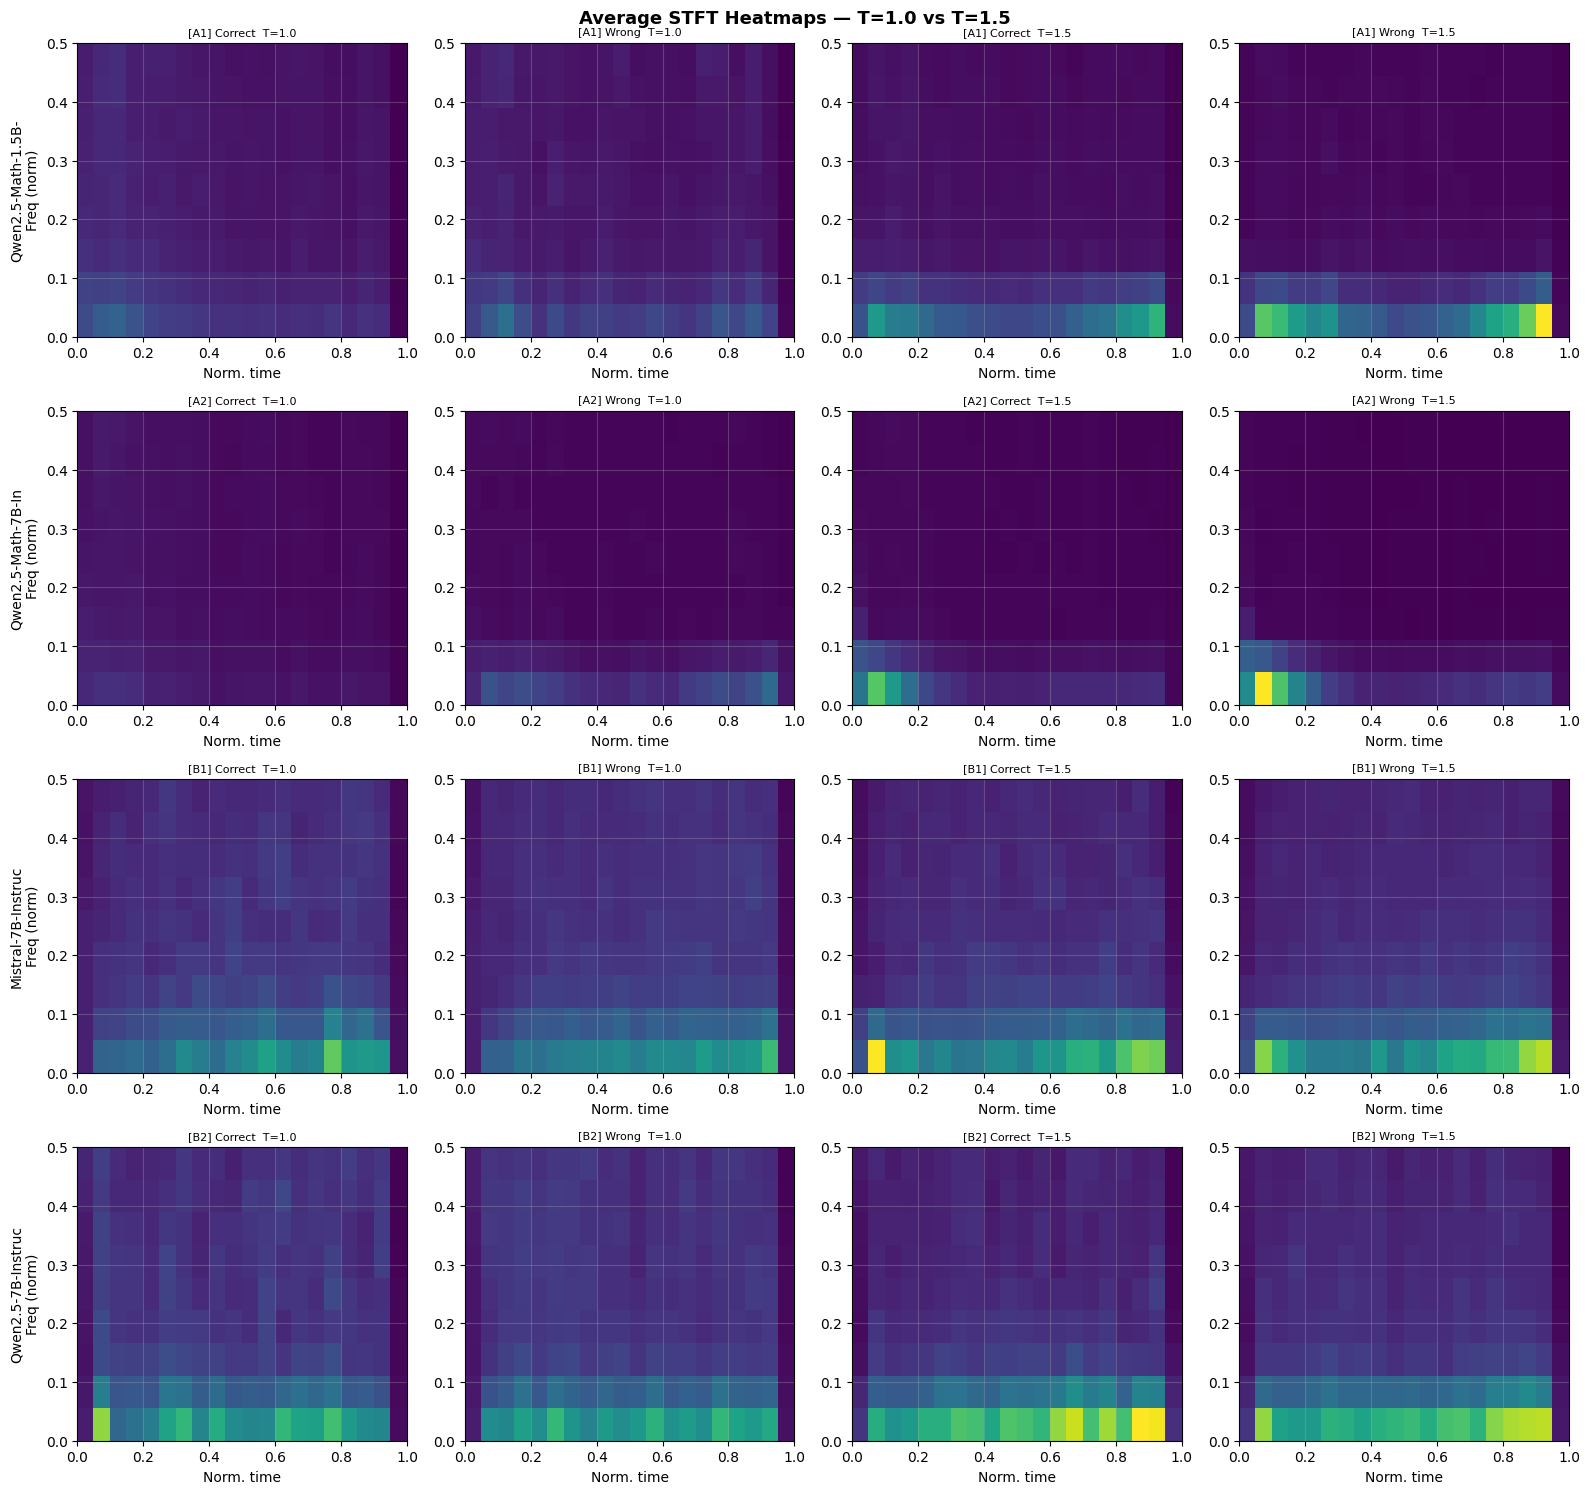

Saved: stft_heatmaps.png


In [11]:
# ── Plot 3: Average STFT heatmaps ─────────────────────────────────────────────
N_TIME, NPERSEG, NOVERLAP = 20, 16, 8

def avg_stft(ents_list, n_time=N_TIME):
    accum, count, freqs_out = None, 0, None
    for ents in ents_list:
        e = np.array(ents, dtype=float)
        if len(e) < 32: continue
        f, t, Zxx = scipy_stft(e - e.mean(), nperseg=NPERSEG, noverlap=NOVERLAP)
        psd = np.abs(Zxx) ** 2
        if psd.shape[1] < 2: continue
        t_g = np.linspace(0, 1, n_time)
        psd_i = np.stack([interp1d(np.linspace(0,1,psd.shape[1]), row)(t_g) for row in psd])
        psd_n = psd_i / (psd_i.sum() + 1e-12)
        accum = psd_n if accum is None else accum + psd_n
        count += 1; freqs_out = f
    return (accum / count if count > 0 else None), freqs_out

fig, axes = plt.subplots(n_plots, 4, figsize=(16, 3.8 * n_plots))
if n_plots == 1: axes = axes[np.newaxis, :]

col_titles = ['Correct  T=1.0', 'Wrong  T=1.0', 'Correct  T=1.5', 'Wrong  T=1.5']
for row_i, tag in enumerate(tags_plot):
    d   = aligned[tag]
    lbl = all_p5[tag]['model'][:18]
    ds  = all_p5[tag]['dataset']
    groups = [
        [e for e, l in zip(d['p5_ents'], d['labels']) if l == 1],
        [e for e, l in zip(d['p5_ents'], d['labels']) if l == 0],
        [e for e, l in zip(d['p4_ents'], d['labels']) if l == 1],
        [e for e, l in zip(d['p4_ents'], d['labels']) if l == 0],
    ]
    hmaps = [avg_stft(g) for g in groups]
    vmx   = max((h[0].max() for h in hmaps if h[0] is not None), default=1.0)

    for col_i, ((hmap, f), ctitle) in enumerate(zip(hmaps, col_titles)):
        ax = axes[row_i, col_i]
        if hmap is not None and f is not None:
            ax.imshow(hmap, aspect='auto', origin='lower',
                      extent=[0, 1, f[0], f[-1]], vmin=0, vmax=vmx, cmap='viridis')
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'[{tag}] {ctitle}', fontsize=8)
        ax.set_xlabel('Norm. time')
        if col_i == 0: ax.set_ylabel(f'{lbl}\nFreq (norm)')

plt.suptitle('Average STFT Heatmaps — T=1.0 vs T=1.5', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'stft_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stft_heatmaps.png')

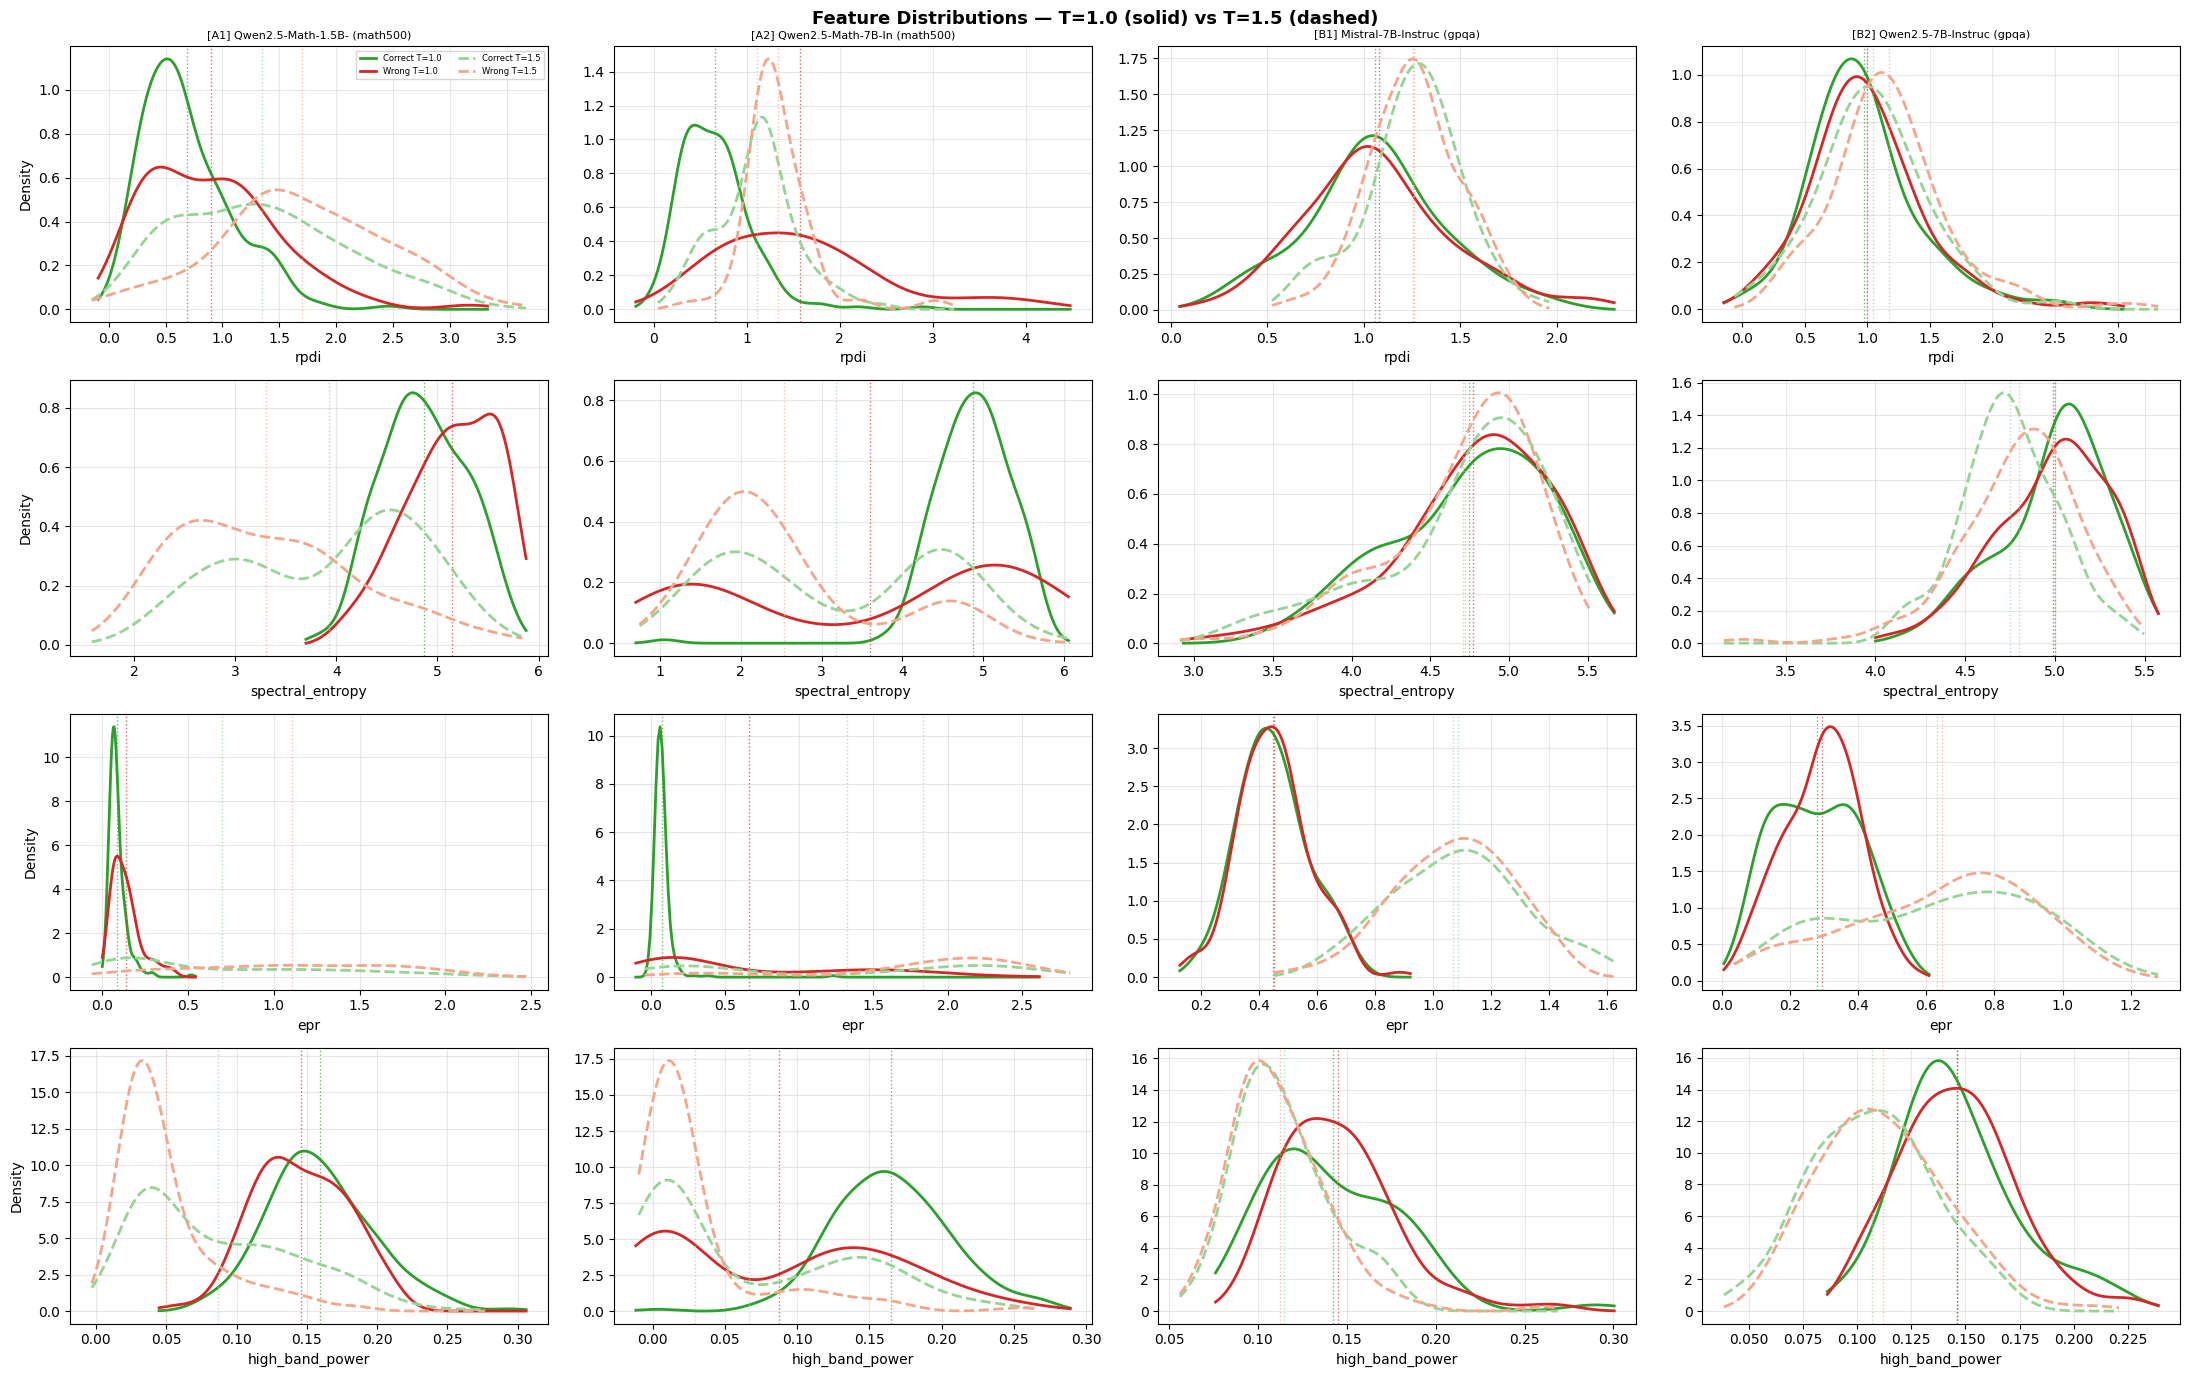

Saved: feature_distributions.png


In [12]:
# ── Plot 4: Feature distributions (KDE) ──────────────────────────────────────
from scipy.stats import gaussian_kde

PLOT_FEATS = ['rpdi', 'spectral_entropy', 'epr', 'high_band_power']

fig, axes = plt.subplots(len(PLOT_FEATS), n_plots,
                          figsize=(5.5 * n_plots, 3.5 * len(PLOT_FEATS)))
if n_plots == 1: axes = axes[:, np.newaxis]

for feat_i, feat_name in enumerate(PLOT_FEATS):
    for col_i, tag in enumerate(tags_plot):
        ax  = axes[feat_i, col_i]
        d   = aligned[tag]
        lbl = all_p5[tag]['model'][:18]
        ds  = all_p5[tag]['dataset']

        for (fa, temp_label, c_col, w_col, ls) in [
            (d['p5_feats'], 'T=1.0', '#2ca02c', '#d62728', '-'),
            (d['p4_feats'], 'T=1.5', '#94d594', '#f5a68a', '--'),
        ]:
            vc = fa[feat_name][d['labels'] == 1]
            vw = fa[feat_name][d['labels'] == 0]
            x0 = min(vc.min(), vw.min()); x1 = max(vc.max(), vw.max())
            xs = np.linspace(x0 - 0.05*(x1-x0), x1 + 0.05*(x1-x0), 200)
            for vals, col, nl in [(vc, c_col, f'Correct {temp_label}'),
                                   (vw, w_col, f'Wrong {temp_label}')]:
                if len(vals) > 2 and np.std(vals) > 1e-8:
                    ax.plot(xs, gaussian_kde(vals)(xs), color=col, ls=ls, lw=2, label=nl)
                    ax.axvline(vals.mean(), color=col, ls=':', lw=1, alpha=0.7)

        if feat_i == 0: ax.set_title(f'[{tag}] {lbl} ({ds})', fontsize=8)
        ax.set_xlabel(feat_name); ax.set_ylabel('Density' if col_i == 0 else '')
        if feat_i == 0 and col_i == 0: ax.legend(fontsize=6, ncol=2)

plt.suptitle('Feature Distributions — T=1.0 (solid) vs T=1.5 (dashed)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_distributions.png')

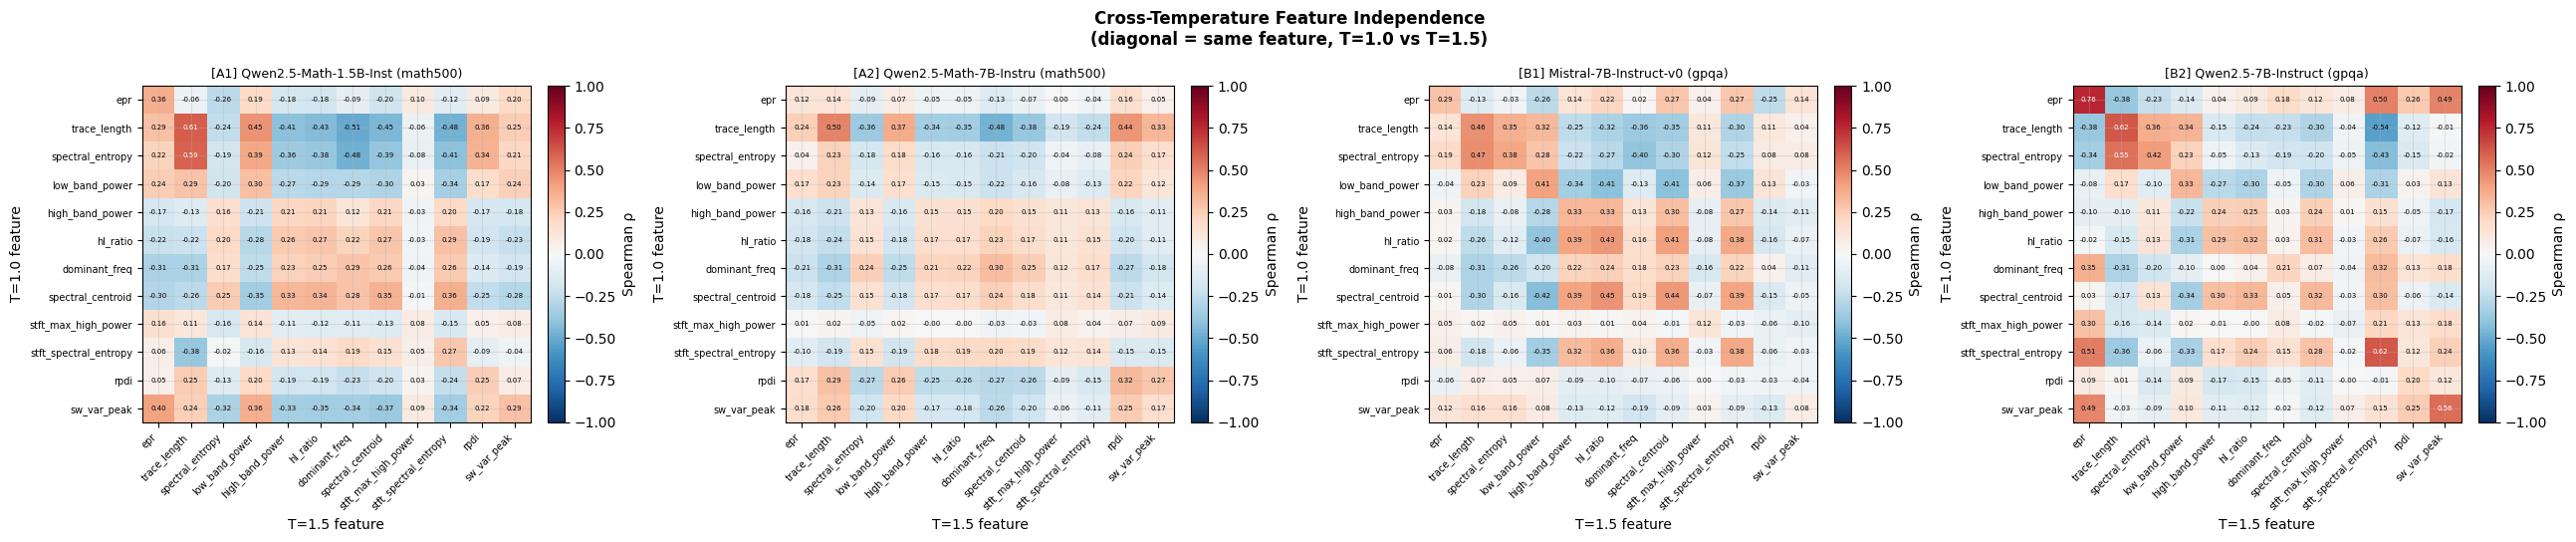

Saved: feature_independence.png


In [13]:
# ── Plot 5: Cross-temperature feature independence ────────────────────────────
# Spearman rho between each T=1.0 feature and each T=1.5 feature.
# Low off-diagonal = independent views (good for fusion).
# Diagonal = same feature at different temperatures.

fig, axes = plt.subplots(1, n_plots, figsize=(6.5 * n_plots, 5.5))
if n_plots == 1: axes = [axes]

for ax, tag in zip(axes, tags_plot):
    d   = aligned[tag]
    lbl = all_p5[tag]['model'][:22]
    ds  = all_p5[tag]['dataset']
    K   = len(FEAT_NAMES)
    rho_mat = np.zeros((K, K))
    for i, fi in enumerate(FEAT_NAMES):
        for j, fj in enumerate(FEAT_NAMES):
            r, _ = spearmanr(d['p5_feats'][fi], d['p4_feats'][fj])
            rho_mat[i, j] = r

    im = ax.imshow(rho_mat, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax.set_xticks(range(K)); ax.set_xticklabels(FEAT_NAMES, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(K)); ax.set_yticklabels(FEAT_NAMES, fontsize=7)
    ax.set_xlabel('T=1.5 feature'); ax.set_ylabel('T=1.0 feature')
    ax.set_title(f'[{tag}] {lbl} ({ds})', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Spearman ρ')
    for i in range(K):
        for j in range(K):
            ax.text(j, i, f'{rho_mat[i,j]:.2f}', ha='center', va='center',
                    fontsize=5, color='white' if abs(rho_mat[i,j]) > 0.55 else 'black')

plt.suptitle('Cross-Temperature Feature Independence\n'
             '(diagonal = same feature, T=1.0 vs T=1.5)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'feature_independence.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_independence.png')

## Cross-Temperature Fusion

Combine spectral features from the aligned T=1.0 and T=1.5 runs for the **same questions**
as independent views, then apply Nadler fusion — the multi-temperature analogue of the
multilingual multi-view idea in EDIS/EPR.

**Ground truth:** correctness at T=1.0
**Features:** `[f_T10, f_T15]` — all 24 features (12 per temperature)

Comparison across three conditions:
- **T=1.0 only** — Nadler best fusion on Phase 5 aligned subset
- **T=1.5 only** — Nadler best fusion on same aligned subset (re-computed)
- **Combined** — Nadler on the doubled 24-feature set

In [ ]:
# ── Cross-temperature Nadler fusion ───────────────────────────────────────────

def best_nadler_on(feats_dict, feat_names, labels_, max_size=3, label=''):
    auc_m, sign_m = {}, {}
    for n_ in feat_names:
        ap, *_ = boot_auc(labels_,  feats_dict[n_])
        an, *_ = boot_auc(labels_, -feats_dict[n_])
        if ap >= an: auc_m[n_], sign_m[n_] = ap, +1
        else:        auc_m[n_], sign_m[n_] = an, -1
    oriented = {n_: feats_dict[n_] * sign_m[n_] for n_ in feat_names}
    rho = {}
    for a, b in itertools.combinations_with_replacement(feat_names, 2):
        r, _ = spearmanr(oriented[a], oriented[b]); rho[(a,b)] = rho[(b,a)] = r
    info = [n_ for n_ in feat_names if auc_m[n_] > 0.50]

    # debug: show search space
    total_combos = sum(
        sum(1 for s in itertools.combinations(info, size))
        for size in range(2, min(len(info)+1, max_size+1))
    )
    print(f'  [{label}] {len(feat_names)} features, {len(info)} informative, '
          f'max_size={max_size} → {total_combos} raw combos')

    best_a, best_lo, best_hi, best_s = 0.0, 0.0, 0.0, None
    checked, skipped = 0, 0
    for size in range(2, min(len(info)+1, max_size+1)):
        size_combos = list(itertools.combinations(info, size))
        valid_in_size = 0
        for s in size_combos:
            if any(abs(rho[(a,b)]) >= 0.75 for a,b in itertools.combinations(s, 2)):
                skipped += 1; continue
            fused, _ = nadler_fuse(*[oriented[n_] for n_ in s])
            a, lo, hi = boot_auc(labels_, fused)
            if a > best_a: best_a, best_lo, best_hi, best_s = a, lo, hi, s
            checked += 1; valid_in_size += 1
        print(f'    size={size}: {len(size_combos)} combos, {valid_in_size} passed ρ-filter, '
              f'best so far={100*best_a:.1f}%')

    print(f'  [{label}] done — checked={checked}, skipped(ρ)={skipped}, best={100*best_a:.1f}%')
    return best_a, best_lo, best_hi, best_s

print(f'{"="*80}\nCROSS-TEMPERATURE FUSION\n{"="*80}')
print(f'{"Model":<28} {"T=1.0 only":>12} {"T=1.5 only":>12} {"Combined":>12} {"Gain":>9}')
print('-' * 76)

fusion_summary = []
for tag in tags_plot:
    d   = aligned[tag]
    mdl = all_p5[tag]['model'][:26]
    ds  = all_p5[tag]['dataset']
    labels = d['labels']

    print(f'\n[{tag}] {mdl} ({ds})')
    print(f'  Running T=1.0 only...')
    a10, lo10, hi10, s10 = best_nadler_on(d['p5_feats'], FEAT_NAMES, labels, label='T=1.0')

    print(f'  Running T=1.5 only...')
    a15, lo15, hi15, s15 = best_nadler_on(d['p4_feats'], FEAT_NAMES, labels, label='T=1.5')

    combined = {f'{n}_T10': d['p5_feats'][n] for n in FEAT_NAMES}
    combined.update({f'{n}_T15': d['p4_feats'][n] for n in FEAT_NAMES})
    FEAT_C = list(combined.keys())
    print(f'  Running combined (max_size=3)...')
    # max_size=3: 24 features × size-5 = 55K subsets; size-3 = ~2K, fast
    ac, loc, hic, sc = best_nadler_on(combined, FEAT_C, labels, max_size=3, label='combined')

    gain = (ac - max(a10, a15)) * 100
    print(f'{mdl:<28} {100*a10:>11.1f}% {100*a15:>11.1f}% {100*ac:>11.1f}% {gain:>+8.1f}pp')
    fusion_summary.append({
        'tag': tag, 'model': mdl, 'dataset': ds,
        'auc_10': a10, 'lo_10': lo10, 'hi_10': hi10, 'sub_10': s10,
        'auc_15': a15, 'lo_15': lo15, 'hi_15': hi15, 'sub_15': s15,
        'auc_comb': ac, 'lo_comb': loc, 'hi_comb': hic, 'sub_comb': sc,
    })

print()
for r in fusion_summary:
    print(f"[{r['tag']}] {r['model']} ({r['dataset']})")
    s10s = '+'.join(r['sub_10']) if r['sub_10'] else 'n/a'
    s15s = '+'.join(r['sub_15']) if r['sub_15'] else 'n/a'
    scs  = '+'.join(r['sub_comb']) if r['sub_comb'] else 'n/a'
    print(f"  T=1.0:    {s10s} = {100*r['auc_10']:.1f}% [{100*r['lo_10']:.1f}, {100*r['hi_10']:.1f}]")
    print(f"  T=1.5:    {s15s} = {100*r['auc_15']:.1f}% [{100*r['lo_15']:.1f}, {100*r['hi_15']:.1f}]")
    print(f"  Combined: {scs} = {100*r['auc_comb']:.1f}% [{100*r['lo_comb']:.1f}, {100*r['hi_comb']:.1f}]")
    print()

save_cache(fusion_summary, os.path.join(BASE_DIR, 'cross_temp_fusion.pkl'))
print('Saved: cross_temp_fusion.pkl')

CROSS-TEMPERATURE FUSION
Model                          T=1.0 only   T=1.5 only     Combined      Gain
----------------------------------------------------------------------------

[A1] Qwen2.5-Math-1.5B-Instruct (math500)
  Running T=1.0 only...
  [T=1.0] 12 features, 12 informative, max_size=3 → 286 raw combos
    size=2: 66 combos, 61 passed ρ-filter, best so far=81.1%
    size=3: 220 combos, 174 passed ρ-filter, best so far=81.5%
  [T=1.0] done — checked=235, skipped(ρ)=51, best=81.5%
  Running T=1.5 only...
  [T=1.5] 12 features, 12 informative, max_size=3 → 286 raw combos
    size=2: 66 combos, 46 passed ρ-filter, best so far=74.0%
    size=3: 220 combos, 85 passed ρ-filter, best so far=74.1%
  [T=1.5] done — checked=131, skipped(ρ)=155, best=74.1%
  Running combined (max_size=3)...
  [combined] 24 features, 24 informative, max_size=3 → 2300 raw combos
    size=2: 276 combos, 251 passed ρ-filter, best so far=81.1%
    size=3: 2024 combos, 1543 passed ρ-filter, best so far=82.3%
 